<a href="https://colab.research.google.com/github/aly-wu/computational-biological-vision-final-project/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Downloads & Function Definitions

In [ ]:
import os
import time
import torch
import IPython
import torchvision
import random
import copy
import imageio

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter

from torchvision import datasets, models, transforms
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
from torch.optim import lr_scheduler

from torch.utils.data import Dataset
from PIL import Image

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.ion()   # interactive mode
%matplotlib inline

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

Mount Google Drive

In [ ]:
# Mount Google Drive to the Colab VM
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = ['KDEF','FER-2013']

# Ensures Python interpreter of the Colab VM can load
# python files from within it
import sys
for fname in FOLDERNAME:
  sys.path.append('/content/drive/My Drive/{}'.format(fname))

Mounted at /content/drive


Define data transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

data_transforms = {'train': train_transform, 'test': test_transform}

Write a general image visualization function

In [ ]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # Pause a bit so that plots are updated

Write a general function to train a model where we:

* Schedule the learning rate
* Save the best model

In the following, parameter scheduler is an LR scheduler object from torch.optim.lr_scheduler.

In [ ]:
# Make directory
os.makedirs('saved', exist_ok=True)

def train_model(kdef_fer, model, criterion, optimizer, scheduler, dataloaders,
                dataset_sizes, writer=None, num_epochs=25):
   """
   kdef_fer: a string which specifies which dataset is being used
   dataloaders: {'train': train_dataloader, 'test': test_dataloader}
   dataset_sizes: {'train': len(train_set), 'test': len(test_set)}
   """

   since = time.time()
   best_model_wts = copy.deepcopy(model.state_dict())
   best_acc = 0.0

   for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'test']:
            if phase == 'train':
                scheduler.step()
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                # Track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            writer.add_scalar(phase+"/loss", epoch_loss, epoch)
            writer.add_scalar(phase+"/acc", epoch_acc, epoch)

            # Deep copy the model w/ best accuracy
            if phase == 'test' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), 'saved/'+ kdef_fer +'.pt')

        print()

   time_elapsed = time.time() - since
   print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
   print('Best val Acc: {:4f}'.format(best_acc))

   # Load best model weights
   model.load_state_dict(best_model_wts)
   return model

Write general formula to display incorrect predictions

In [ ]:
def show_incorrect_examples(images, labels, preds, num=5):
    plt.figure(figsize=(15, 5))
    for i in range(min(num, len(images))):
        plt.subplot(1, num, i+1)
        plt.imshow(images[i])
        plt.title(f'Pred: {preds[i]}\nActual: {labels[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# FER-2013 Dataset

## Load Data

Load FER-2013 Dataset

In [ ]:
# 80% train, 20% test ratio
FER2013_dataset = ImageFolder('/content/drive/My Drive/FER-2013', transform=None)

image_count = len(FER2013_dataset)
train_indices = []
test_indices = []
for i in range(image_count):
  # Put twenty percent of the images in the test set,
  # Matching the pre-partioned train:test ratio in FER-2013
  if random.random() < .2:
    test_indices.append(i)
  else:
    train_indices.append(i)

FER2013_test_set = torch.utils.data.Subset(FER2013_dataset, test_indices)
FER2013_train_set = torch.utils.data.Subset(FER2013_dataset, train_indices)

FER2013_train_set.dataset.transform = train_transform
FER2013_test_set.dataset.transform = test_transform

FER2013_class_names = FER2013_dataset.classes

# batch size, num_workers, shuffle matches Ahkand et. al 2021 methods
FER2013_train_loader = torch.utils.data.DataLoader(FER2013_train_set, batch_size=8,
                                                shuffle=True, num_workers=4)
FER2013_test_loader = torch.utils.data.DataLoader(FER2013_test_set, batch_size=8,
                                               shuffle=True, num_workers=4)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Visualize a few images from FER-2013

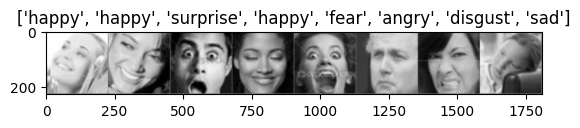

In [ ]:
# Get a batch of training data
inputs, classes = next(iter(FER2013_train_loader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[FER2013_class_names[x] for x in classes])

## Finetuning the convnet

Load a pretrained model and reset final fully connected layer.

In [ ]:
FER2013_model_ft = models.densenet161(pretrained=True)
FER2013_num_ftrs = FER2013_model_ft.classifier.in_features

# Modify classifier layer
FER2013_model_ft.classifier = nn.Linear(FER2013_num_ftrs, len(FER2013_class_names))

FER2013_model_ft = FER2013_model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
FER2013_optimizer_ft = optim.SGD(FER2013_model_ft.parameters(), lr=0.0005, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
FER2013_exp_lr_scheduler = lr_scheduler.StepLR(FER2013_optimizer_ft, step_size=6, gamma=0.1)

writer = SummaryWriter('./logs/visionfinalproject')

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet161_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet161_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet161-8d451a50.pth" to /root/.cache/torch/hub/checkpoints/densenet161-8d451a50.pth
100%|██████████| 110M/110M [00:01<00:00, 112MB/s] 


## Train and evaluate

In [ ]:
FER2013_dataloaders = {'train': FER2013_train_loader, 'test': FER2013_test_loader}
FER2013_dataset_sizes = {'train': len(FER2013_train_set), 'test': len(FER2013_test_set)}

FER2013_model_ft = train_model('fer', FER2013_model_ft, criterion, FER2013_optimizer_ft, FER2013_exp_lr_scheduler,
                       FER2013_dataloaders, FER2013_dataset_sizes, writer, num_epochs=20)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 0/19
----------


100%|██████████| 298/298 [03:58<00:00,  1.25it/s]


train Loss: 1.7998 Acc: 0.2654


100%|██████████| 71/71 [00:57<00:00,  1.23it/s]


...

test Loss: 1.4900 Acc: 0.5634

Epoch 19/19
----------


100%|██████████| 298/298 [01:02<00:00,  4.79it/s]


train Loss: 0.0766 Acc: 0.9887


100%|██████████| 71/71 [00:05<00:00, 11.88it/s]

test Loss: 1.5176 Acc: 0.5704

Training complete in 27m 9s
Best val Acc: 0.584507


## Load and test model

In [ ]:
# Load the pre-trained model weights
FER2013_model_ft.load_state_dict(torch.load('saved/fer.pt'))
FER2013_model_ft.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(96, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(192, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (rel

In [ ]:
import imageio
FER2013_total = 0
FER2013_correct = 0

FER2013_incorrect_images = []
FER2013_incorrect_labels = []
FER2013_incorrect_preds = []

classes = {
    0 : "fear",
    1 : "angry",
    2 : "disgust",
    3 : "happy",
    4 : "neutral",
    5 : "sad",
    6 : "surprise"
}

for inputs, labels in tqdm(FER2013_dataloaders['test']):
    FER2013_inputs = inputs.to(device)
    FER2013_labels = labels.to(device)

    FER2013_outputs = FER2013_model_ft(FER2013_inputs)
    _, FER2013_preds = torch.max(FER2013_outputs, 1)

    FER2013_total += FER2013_inputs.size(0)
    for i in range(FER2013_inputs.size(0)):
        if FER2013_preds[i] == FER2013_labels[i]:
            FER2013_correct += 1
        else:
            # Save incorrect image and info
            img = inputs[i].cpu().numpy().transpose(1, 2, 0)
            img = np.clip(img * np.array([0.229, 0.224, 0.225]) +
                          np.array([0.485, 0.456, 0.406]), 0, 1)
            FER2013_incorrect_images.append(img)
            FER2013_incorrect_labels.append(classes[int(FER2013_labels[i])])
            FER2013_incorrect_preds.append(classes[int(FER2013_preds[i])])

            image_index = FER2013_total - inputs.size(0) + i + 1

            print("image no ", str(image_index), "  original class : ",
                  classes[int(FER2013_labels.data[i].cpu().numpy())],
                  " predicted class: ", classes[int(FER2013_preds.data[i].cpu().numpy())])

print(f"Correct: {FER2013_correct}, Total: {FER2013_total}, Accuracy: {FER2013_correct / FER2013_total:.2%}")

  4%|▍         | 3/71 [00:00<00:11,  5.76it/s]

image no  8   original class :  sad  predicted class:  disgust
image no  8   original class :  disgust  predicted class:  fear
image no  8   original class :  disgust  predicted class:  surprise
image no  8   original class :  disgust  predicted class:  sad
image no  8   original class :  sad  predicted class:  neutral
image no  8   original class :  surprise  predicted class:  neutral
image no  16   original class :  angry  predicted class:  fear
image no  16   original class :  neutral  predicted class:  fear
image no  16   original class :  neutral  predicted class:  happy
image no  16   original class :  surprise  predicted class:  neutral
image no  24   original class :  sad  predicted class:  angry
image no  24   original class :  neutral  predicted class:  sad
image no  24   original class :  disgust  predicted class:  sad
image no  24   original class :  angry  predicted class:  sad


  7%|▋         | 5/71 [00:00<00:07,  8.30it/s]

image no  32   original class :  sad  predicted class:  neutral
image no  32   original class :  angry  predicted class:  sad
image no  32   original class :  fear  predicted class:  neutral
image no  32   original class :  surprise  predicted class:  neutral
image no  40   original class :  happy  predicted class:  disgust
image no  40   original class :  neutral  predicted class:  sad
image no  40   original class :  disgust  predicted class:  angry
image no  40   original class :  happy  predicted class:  sad
image no  48   original class :  fear  predicted class:  neutral


 13%|█▎        | 9/71 [00:01<00:05, 11.42it/s]

...

image no  520   original class :  surprise  predicted class:  disgust
image no  520   original class :  sad  predicted class:  neutral
image no  520   original class :  sad  predicted class:  neutral
image no  520   original class :  sad  predicted class:  neutral
image no  520   original class :  disgust  predicted class:  fear
image no  528   original class :  surprise  predicted class:  fear
image no  528   original class :  neutral  predicted class:  sad
image no  528   original class :  disgust  predicted class:  angry
image no  528   original class :  fear  predicted class:  sad
image no  528   original class :  disgust  predicted class:  neutral
image no  528   original class :  disgust  predicted class:  surprise
image no  536   original class :  angry  predicted class:  fear
image no  536   original class :  disgust  predicted class:  fear
image no  536   original class :  neutral  predicted class:  fear
image no  536   original class :  happy  predicted class:  neutral
image 

 97%|█████████▋| 69/71 [00:06<00:00, 12.24it/s]

image no  544   original class :  disgust  predicted class:  sad
image no  544   original class :  sad  predicted class:  neutral
image no  544   original class :  disgust  predicted class:  angry
image no  552   original class :  sad  predicted class:  disgust
image no  552   original class :  disgust  predicted class:  sad
image no  552   original class :  sad  predicted class:  disgust
image no  552   original class :  fear  predicted class:  disgust
image no  552   original class :  surprise  predicted class:  happy
image no  560   original class :  disgust  predicted class:  neutral
image no  560   original class :  surprise  predicted class:  disgust
image no  560   original class :  fear  predicted class:  neutral
image no  560   original class :  fear  predicted class:  disgust


100%|██████████| 71/71 [00:06<00:00, 11.09it/s]

image no  568   original class :  neutral  predicted class:  sad
image no  568   original class :  fear  predicted class:  happy
image no  568   original class :  happy  predicted class:  disgust
Correct: 332, Total: 568, Accuracy: 58.45%


Display incorrect predictions

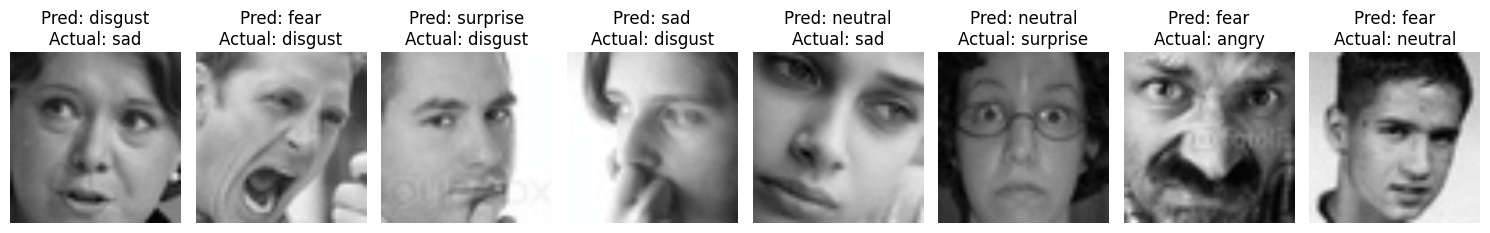

In [ ]:
show_incorrect_examples(FER2013_incorrect_images, FER2013_incorrect_labels, FER2013_incorrect_preds, num=8)

# KDEF Dataset

## Load Data

Load KDEF Dataset

In [ ]:
# 80% train, 20% test ratio

KDEF_dataset = ImageFolder('/content/drive/My Drive/KDEF', transform=None)

image_count = len(KDEF_dataset)
train_indices = []
test_indices = []
for i in range(image_count):
  # Put twenty percent of the images in the test set,
  # Matching the pre-partioned train:test ratio in FER-2013
  if random.random() < .2:
    test_indices.append(i)
  else:
    train_indices.append(i)

KDEF_test_set = torch.utils.data.Subset(KDEF_dataset, test_indices)
KDEF_train_set = torch.utils.data.Subset(KDEF_dataset, train_indices)

KDEF_train_set.dataset.transform = train_transform
KDEF_test_set.dataset.transform = test_transform

KDEF_class_names = KDEF_dataset.classes

# batch size, num_workers, shuffle matches Ahkand et. al 2021 methods
KDEF_train_loader = torch.utils.data.DataLoader(KDEF_train_set, batch_size=8,
                                                shuffle=True, num_workers=4)
KDEF_test_loader = torch.utils.data.DataLoader(KDEF_test_set, batch_size=8,
                                               shuffle=True, num_workers=4)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Visualize a few images from KDEF

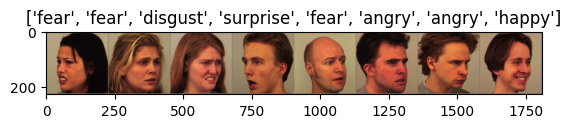

In [ ]:
# Get a batch of training data
inputs, classes = next(iter(KDEF_train_loader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[KDEF_class_names[x] for x in classes])

## Finetuning the convnet

Load a pretrained model and reset final fully connected layer.

In [ ]:
KDEF_model_ft = models.densenet161(pretrained=True)
KDEF_num_ftrs = KDEF_model_ft.classifier.in_features
KDEF_model_ft.classifier = nn.Linear(KDEF_num_ftrs, len(KDEF_class_names))

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
KDEF_model_ft = KDEF_model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
KDEF_optimizer_ft = optim.SGD(KDEF_model_ft.parameters(), lr=0.0005, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
KDEF_exp_lr_scheduler = lr_scheduler.StepLR(KDEF_optimizer_ft, step_size=6, gamma=0.1)

writer = SummaryWriter('./logs/visionfinalproject')

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet161_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet161_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet161-8d451a50.pth" to /root/.cache/torch/hub/checkpoints/densenet161-8d451a50.pth
100%|██████████| 110M/110M [00:00<00:00, 174MB/s]


## Train and evaluate

In [ ]:
KDEF_dataloaders = {'train': KDEF_train_loader, 'test': KDEF_test_loader}
KDEF_dataset_sizes = {'train': len(KDEF_train_set), 'test': len(KDEF_test_set)}

KDEF_model_ft = train_model('kdef', KDEF_model_ft, criterion, KDEF_optimizer_ft, KDEF_exp_lr_scheduler,
                       KDEF_dataloaders, KDEF_dataset_sizes, writer, num_epochs=20)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 0/19
----------


100%|██████████| 293/293 [03:39<00:00,  1.34it/s]


train Loss: 1.1031 Acc: 0.5855


100%|██████████| 75/75 [00:52<00:00,  1.42it/s]


...

test Loss: 0.1113 Acc: 0.9667

Epoch 19/19
----------


100%|██████████| 293/293 [01:02<00:00,  4.66it/s]


train Loss: 0.0336 Acc: 0.9944


100%|██████████| 75/75 [00:06<00:00, 11.84it/s]

test Loss: 0.1327 Acc: 0.9583

Training complete in 26m 19s
Best val Acc: 0.966667


## Load and test model

In [ ]:
KDEF_model_ft.load_state_dict(torch.load('saved/kdef.pt'))
KDEF_model_ft.eval() # Set to eval mode

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(96, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(192, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (rel

In [ ]:
KDEF_total = 0
KDEF_correct = 0

KDEF_incorrect_images = []
KDEF_incorrect_labels = []
KDEF_incorrect_preds = []

classes = {
    0 : "fear",
    1 : "angry",
    2 : "disgust",
    3 : "happy",
    4 : "neutral",
    5 : "sad",
    6 : "surprise"
    }

for inputs, labels in tqdm(KDEF_test_loader):
    KDEF_inputs = inputs.to(device)
    KDEF_labels = labels.to(device)

    KDEF_outputs = KDEF_model_ft(KDEF_inputs)
    _, KDEF_preds = torch.max(KDEF_outputs, 1)

    KDEF_total += KDEF_inputs.size(0)
    for i in range(KDEF_inputs.size(0)):
        if KDEF_preds[i] == KDEF_labels[i]:
            KDEF_correct += 1
        else:
            # Save incorrect image and info
            img = KDEF_inputs[i].cpu().numpy().transpose(1, 2, 0)
            img = np.clip(img * np.array([0.229, 0.224, 0.225]) +
                          np.array([0.485, 0.456, 0.406]), 0, 1)
            KDEF_incorrect_images.append(img)
            KDEF_incorrect_labels.append(classes[int(KDEF_labels[i])])
            KDEF_incorrect_preds.append(classes[int(KDEF_preds[i])])


            image_index = KDEF_total - inputs.size(0) + i + 1

            print("image no ", str(image_index), "  original class : ",
                  classes[int(KDEF_labels.data[i].cpu().numpy())],
                  " predicted class: ", classes[int(KDEF_preds.data[i].cpu().numpy())])

print(f"Correct: {KDEF_correct}, Total: {KDEF_total}, Accuracy: {KDEF_correct / KDEF_total:.2%}")

 12%|█▏        | 9/75 [00:01<00:06,  9.97it/s]

image no  54   original class :  fear  predicted class:  angry


 20%|██        | 15/75 [00:01<00:05, 11.78it/s]

image no  104   original class :  disgust  predicted class:  surprise
image no  112   original class :  disgust  predicted class:  surprise


 23%|██▎       | 17/75 [00:02<00:05, 11.28it/s]

...

image no  479   original class :  angry  predicted class:  sad
image no  494   original class :  fear  predicted class:  neutral


 97%|█████████▋| 73/75 [00:06<00:00, 14.39it/s]

image no  561   original class :  sad  predicted class:  fear
image no  566   original class :  sad  predicted class:  neutral
image no  585   original class :  angry  predicted class:  fear
image no  588   original class :  fear  predicted class:  angry


100%|██████████| 75/75 [00:06<00:00, 11.34it/s]

Correct: 580, Total: 600, Accuracy: 96.67%


Display incorrect predictions

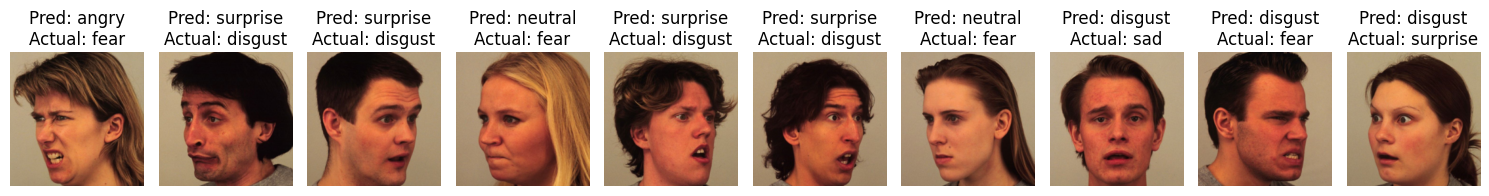

In [ ]:
show_incorrect_examples(KDEF_incorrect_images, KDEF_incorrect_labels, KDEF_incorrect_preds, num=10)

# Bias Evaluation

## Load JAFFE & DiverseFACES datasets

In [ ]:
FOLDERNAME = ['jaffe','DiverseFACES']

# Ensures Python interpreter of the Colab VM can load python files from within it
import sys
for fname in FOLDERNAME:
  sys.path.append('/content/drive/My Drive/{}'.format(fname))

Create new data class to parse through JAFFE dataset file organization

In [ ]:
class JAFFEEmotionDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_files = [f for f in os.listdir(image_dir) if f.endswith('.tif') or f.endswith('.tiff')]
        self.transform = transform

        self.classes = ['afraid', 'angry', 'disgust', 'happy', 'neutral', 'sad', 'surprised']

        self.emotion_map = {
            'FE': 'afraid',
            'AN': 'angry',
            'DI': 'disgust',
            'HA': 'happy',
            'NE': 'neutral',
            'SA': 'sad',
            'SU': 'surprised'}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)

        # Example img_name) KA.HA1.34
        emotion_str = self.emotion_map.get(img_name.split('.')[1][:2])
        label = self.classes.index(emotion_str)

        # Load TIFF image using PIL
        image = Image.open(img_path).convert('RGB')  # Ensures it's in 3-channel format

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# Load JAFFE dataset
jaffe_dataset = JAFFEEmotionDataset(image_dir='/content/drive/My Drive/jaffe', transform= train_transform)

jaffe_class_names = jaffe_dataset.classes # currently has no attribute named classes

jaffe_dataset_size = len(jaffe_dataset)

# batch size, num_workers, shuffle matches Ahkand et. al 2021 methods
jaffe_dataloader = torch.utils.data.DataLoader(jaffe_dataset, batch_size=8,
                                                shuffle=True, num_workers=4)

Visualize a few images

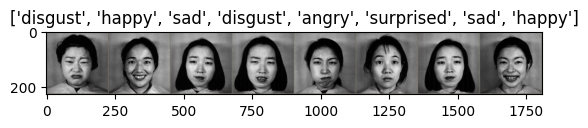

In [ ]:
# Get a batch of training data
inputs, classes = next(iter(jaffe_dataloader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[jaffe_class_names[x] for x in classes])

Create new data class to parse through DiverseFACES dataset file organization

In [ ]:
class DiverseFACESEmotionDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg'))]
        self.transform = transform

        # DiverseFACES has no class surprised, but perserve in classes to keep indicies matched across models
        self.classes = ['fear', 'angry', 'disgust', 'happy', 'neutral', 'sad', 'surprise']

        self.emotion_map = {
            'a': 'angry',
            'd': 'disgust',
            'f': 'fear',
            'h': 'happy',
            'n': 'neutral',
            's': 'sad'
        }

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)

        # Extract labels from filename
        # Example img_name = 121_y_m_l_s_a
        parts = img_name.split('_')
        emotion_code = img_name.split('_')[1]
        race_code = img_name.split('_')[3]
        age_code = img_name.split('_')[5]

        # Convert to label integers
        emotion_label = self.classes.index(self.emotion_map.get(img_name.split('_')[4], 'unknown'))

        # Load image
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # You can return one or all labels, depending on task
        return image, emotion_label

In [ ]:
# Load DiverseFACES dataset
DiverseFACES_dataset = DiverseFACESEmotionDataset(image_dir = '/content/drive/My Drive/DiverseFACES', transform = train_transform)

DiverseFACES_class_names = DiverseFACES_dataset.classes

# batch size, num_workers, shuffle matches Ahkand et. al 2021 methods
DiverseFACES_dataloader = torch.utils.data.DataLoader(DiverseFACES_dataset, batch_size=8,
                                                shuffle=True, num_workers=4)

Visualize a few images

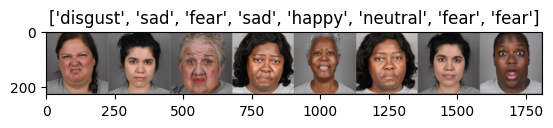

In [ ]:
# Get a batch of training data
inputs, classes = next(iter(DiverseFACES_dataloader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

class_indices = [label.item() for label in classes]
imshow(out, title=[DiverseFACES_class_names[idx] for idx in class_indices])

## FER-2013 Trained Model


In [ ]:
FER2013_model_ft.eval() # Set to eval mode

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(96, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(192, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (rel

### Assess on JAFFE dataset

In [ ]:
FERxJAFFE_total = 0
FERxJAFFE_correct = 0

FERxJAFFE_incorrect_images = []
FERxJAFFE_incorrect_labels = []
FERxJAFFE_incorrect_preds = []

classes = {
    0 : "fear",
    1 : "angry",
    2 : "disgust",
    3 : "happy",
    4 : "neutral",
    5 : "sad",
    6 : "surprise"
    }

# Storage for confusion matrix
FERxJAFFE_all_preds = []
FERxJAFFE_all_labels = []

for inputs, labels in tqdm(jaffe_dataloader):
    FERxJAFFE_inputs = inputs.to(device)
    FERxJAFFE_labels = labels.to(device)

    FERxJAFFE_outputs = FER2013_model_ft(FERxJAFFE_inputs)
    _, FERxJAFFE_preds = torch.max(FERxJAFFE_outputs, 1)

    FERxJAFFE_total += inputs.size(0)
    for i in range(FERxJAFFE_inputs.size(0)):
        true_label = FERxJAFFE_labels[i].cpu().item()
        pred_label = FERxJAFFE_preds[i].cpu().item()
        FERxJAFFE_all_preds.append(pred_label)
        FERxJAFFE_all_labels.append(true_label)

        if FERxJAFFE_preds[i] == labels[i]:
            FERxJAFFE_correct += 1
        else:
            # Save incorrect image and info
            img = inputs[i].cpu().numpy().transpose(1, 2, 0)
            img = np.clip(img * np.array([0.229, 0.224, 0.225]) +
                          np.array([0.485, 0.456, 0.406]), 0, 1)
            FERxJAFFE_incorrect_images.append(img)
            FERxJAFFE_incorrect_labels.append(classes[int(FERxJAFFE_labels[i])])
            FERxJAFFE_incorrect_preds.append(classes[int(FERxJAFFE_preds[i])])

            image_index = FERxJAFFE_total - inputs.size(0) + i + 1

            print("image no ", str(image_index), "  original class : ",
                  classes[int(FERxJAFFE_labels.data[i].cpu().numpy())],
                  " predicted class: ", classes[int(FERxJAFFE_preds.data[i].cpu().numpy())])
# Accuracy
print(f"Correct: {FERxJAFFE_correct}, Total: {FERxJAFFE_total}, Accuracy: {FERxJAFFE_correct / FERxJAFFE_total:.2%}")

  7%|▋         | 2/27 [00:01<00:12,  1.97it/s]

image no  3   original class :  disgust  predicted class:  neutral
image no  5   original class :  sad  predicted class:  neutral
image no  6   original class :  fear  predicted class:  happy
image no  8   original class :  sad  predicted class:  neutral
image no  9   original class :  disgust  predicted class:  sad
image no  10   original class :  fear  predicted class:  neutral
image no  11   original class :  fear  predicted class:  sad
image no  14   original class :  sad  predicted class:  fear


 11%|█         | 3/27 [00:01<00:07,  3.11it/s]

image no  17   original class :  disgust  predicted class:  sad
image no  19   original class :  neutral  predicted class:  sad
image no  20   original class :  happy  predicted class:  sad
image no  23   original class :  surprise  predicted class:  sad
image no  24   original class :  sad  predicted class:  neutral
image no  25   original class :  sad  predicted class:  neutral


 19%|█▊        | 5/27 [00:01<00:05,  4.33it/s]

...

image no  164   original class :  happy  predicted class:  sad
image no  165   original class :  angry  predicted class:  neutral
image no  166   original class :  sad  predicted class:  neutral
image no  167   original class :  surprise  predicted class:  neutral
image no  168   original class :  disgust  predicted class:  neutral
image no  169   original class :  fear  predicted class:  surprise
image no  174   original class :  angry  predicted class:  sad
image no  175   original class :  surprise  predicted class:  happy
image no  176   original class :  happy  predicted class:  neutral
image no  177   original class :  fear  predicted class:  surprise
image no  179   original class :  sad  predicted class:  neutral
image no  180   original class :  surprise  predicted class:  neutral
image no  182   original class :  happy  predicted class:  sad
image no  183   original class :  surprise  predicted class:  neutral
image no  184   original class :  fear  predicted class:  sad


 96%|█████████▋| 26/27 [00:03<00:00, 12.78it/s]

image no  185   original class :  angry  predicted class:  neutral
image no  189   original class :  surprise  predicted class:  sad
image no  190   original class :  angry  predicted class:  neutral
image no  191   original class :  fear  predicted class:  sad
image no  192   original class :  angry  predicted class:  neutral
image no  193   original class :  sad  predicted class:  neutral
image no  195   original class :  sad  predicted class:  neutral
image no  196   original class :  angry  predicted class:  sad
image no  197   original class :  disgust  predicted class:  sad
image no  198   original class :  surprise  predicted class:  neutral
image no  199   original class :  disgust  predicted class:  sad
image no  200   original class :  disgust  predicted class:  neutral
image no  201   original class :  angry  predicted class:  sad
image no  202   original class :  sad  predicted class:  neutral
image no  203   original class :  sad  predicted class:  neutral
image no  207   

100%|██████████| 27/27 [00:03<00:00,  7.23it/s]

image no  209   original class :  angry  predicted class:  sad
image no  210   original class :  fear  predicted class:  neutral
image no  212   original class :  sad  predicted class:  surprise
image no  213   original class :  fear  predicted class:  neutral
Correct: 75, Total: 213, Accuracy: 35.21%


Display incorrect predictions

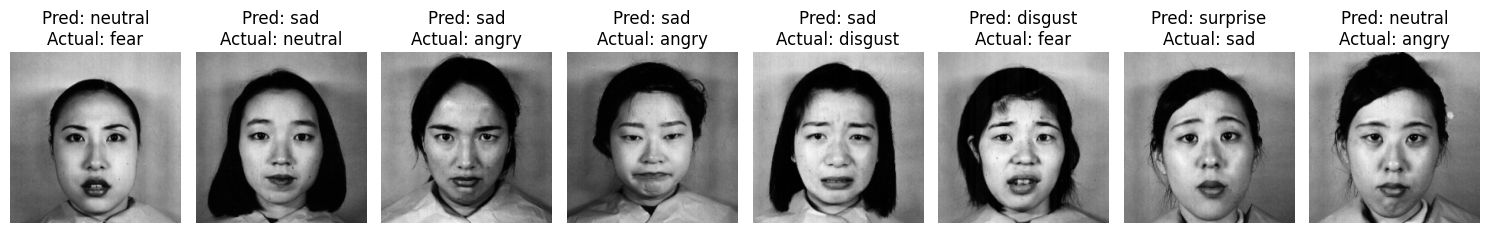

In [ ]:
show_incorrect_examples(FERxJAFFE_incorrect_images, FERxJAFFE_incorrect_labels, FERxJAFFE_incorrect_preds, num=8)

### Assess on DiverseFACES dataset

In [ ]:
FERxDiverse_total = 0
FERxDiverse_correct = 0

FERxDiverse_incorrect_images = []
FERxDiverse_incorrect_labels = []
FERxDiverse_incorrect_preds = []

classes = {
    0 : "fear",
    1 : "angry",
    2 : "disgust",
    3 : "happy",
    4 : "neutral",
    5 : "sad",
    6 : "surprise"
    }

# Storage for confusion matrix
FERxDiverse_all_preds = []
FERxDiverse_all_labels = []

# labels = emotion
for inputs, labels in tqdm(DiverseFACES_dataloader):
    FERxDiverse_inputs = inputs.to(device)
    FERxDiverse_labels = labels.to(device)

    FERxDiverse_outputs = FER2013_model_ft(FERxDiverse_inputs)
    _, FERxDiverse_preds = torch.max(FERxDiverse_outputs, 1)

    FERxDiverse_total += inputs.size(0)
    for i in range(FERxDiverse_inputs.size(0)):
        true_label = FERxDiverse_labels[i].cpu().item()
        pred_label = FERxDiverse_preds[i].cpu().item()
        FERxDiverse_all_preds.append(pred_label)
        FERxDiverse_all_labels.append(true_label)

        if pred_label == true_label:
            FERxDiverse_correct += 1

        else:
            # Save incorrect image and info
            img = inputs[i].cpu().numpy().transpose(1, 2, 0)
            img = np.clip(img * np.array([0.229, 0.224, 0.225]) +
                          np.array([0.485, 0.456, 0.406]), 0, 1)
            FERxDiverse_incorrect_images.append(img)
            FERxDiverse_incorrect_labels.append(classes[int(FERxDiverse_labels[i])])
            FERxDiverse_incorrect_preds.append(classes[int(FERxDiverse_preds[i])])

            image_index = FERxDiverse_total - inputs.size(0) + i + 1

            print("image no ", str(image_index), "  original class : ",
                  classes[int(labels.data[i].cpu().numpy())],
                  " predicted class: ", classes[int(FERxDiverse_preds.data[i].cpu().numpy())])


print(f"Correct: {FERxDiverse_correct}, Total: {FERxDiverse_total}, Accuracy: {FERxDiverse_correct / FERxDiverse_total:.2%}")

  2%|▏         | 1/54 [00:02<02:10,  2.46s/it]

image no  3   original class :  disgust  predicted class:  neutral
image no  4   original class :  sad  predicted class:  neutral
image no  5   original class :  disgust  predicted class:  fear


  4%|▎         | 2/54 [00:02<01:00,  1.17s/it]

image no  9   original class :  happy  predicted class:  neutral
image no  10   original class :  happy  predicted class:  neutral
image no  13   original class :  angry  predicted class:  neutral
image no  14   original class :  disgust  predicted class:  neutral
image no  16   original class :  disgust  predicted class:  neutral


  6%|▌         | 3/54 [00:03<00:41,  1.23it/s]

...

image no  410   original class :  sad  predicted class:  neutral
image no  411   original class :  angry  predicted class:  neutral
image no  412   original class :  disgust  predicted class:  neutral
image no  413   original class :  sad  predicted class:  neutral
image no  415   original class :  happy  predicted class:  neutral
image no  416   original class :  angry  predicted class:  neutral


 98%|█████████▊| 53/54 [00:22<00:00,  2.90it/s]

image no  417   original class :  sad  predicted class:  neutral
image no  418   original class :  fear  predicted class:  neutral
image no  419   original class :  sad  predicted class:  neutral
image no  420   original class :  sad  predicted class:  neutral
image no  421   original class :  sad  predicted class:  neutral
image no  422   original class :  angry  predicted class:  neutral
image no  423   original class :  angry  predicted class:  neutral


100%|██████████| 54/54 [00:23<00:00,  2.32it/s]

image no  425   original class :  disgust  predicted class:  neutral
image no  426   original class :  angry  predicted class:  fear
image no  428   original class :  fear  predicted class:  happy
image no  429   original class :  sad  predicted class:  neutral
image no  430   original class :  sad  predicted class:  neutral
image no  431   original class :  fear  predicted class:  neutral
image no  432   original class :  sad  predicted class:  neutral
Correct: 130, Total: 432, Accuracy: 30.09%


Display incorrect predictions

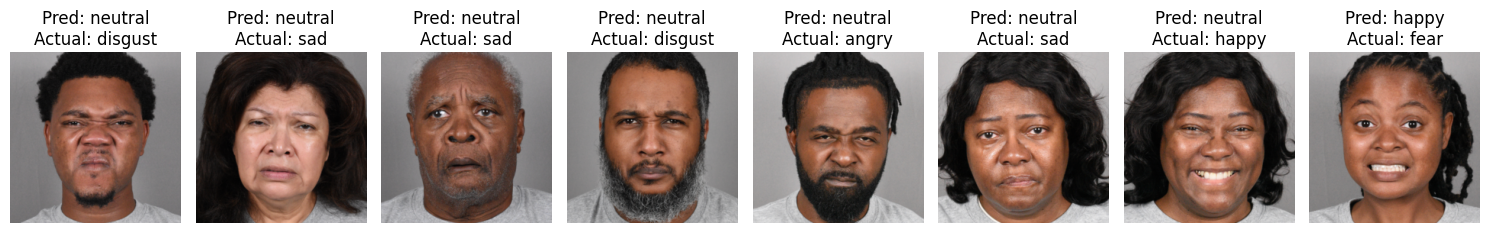

In [ ]:
show_incorrect_examples(FERxDiverse_incorrect_images, FERxDiverse_incorrect_labels, FERxDiverse_incorrect_preds, num=8)

## KDEF Trained Model


In [ ]:
KDEF_model_ft.eval() # Set to eval mode

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(96, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(192, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (rel

### Assess on JAFFE dataset

In [ ]:
KDEFxJAFFE_total = 0
KDEFxJAFFE_correct = 0

KDEFxJAFFE_incorrect_images = []
KDEFxJAFFE_incorrect_labels = []
KDEFxJAFFE_incorrect_preds = []

classes = {
    0 : "afraid",
    1 : "angry",
    2 : "disgust",
    3 : "happy",
    4 : "neutral",
    5 : "sad",
    6 : "surprise"
    }


# Storage for confusion matrix
KDEFxJAFFE_all_preds = []
KDEFxJAFFE_all_labels = []

for inputs, labels in tqdm(jaffe_dataloader):
    KDEFxJAFFE_inputs = inputs.to(device)
    KDEFxJAFFE_labels = labels.to(device)

    KDEFxJAFFE_outputs = KDEF_model_ft(KDEFxJAFFE_inputs)
    _, KDEFxJAFFE_preds = torch.max(KDEFxJAFFE_outputs, 1)

    KDEFxJAFFE_total += inputs.size(0)
    for i in range(KDEFxJAFFE_inputs.size(0)):
        true_label = KDEFxJAFFE_labels[i].cpu().item()
        pred_label = KDEFxJAFFE_preds[i].cpu().item()
        KDEFxJAFFE_all_preds.append(pred_label)
        KDEFxJAFFE_all_labels.append(true_label)

        if pred_label == true_label:
            KDEFxJAFFE_correct += 1
        else:
            # Save incorrect image and info
            img = KDEFxJAFFE_inputs[i].cpu().numpy().transpose(1, 2, 0)
            img = np.clip(img * np.array([0.229, 0.224, 0.225]) +
                          np.array([0.485, 0.456, 0.406]), 0, 1)
            KDEFxJAFFE_incorrect_images.append(img)
            KDEFxJAFFE_incorrect_labels.append(classes[int(KDEFxJAFFE_labels[i])])
            KDEFxJAFFE_incorrect_preds.append(classes[int(KDEFxJAFFE_preds[i])])

            image_index = KDEFxJAFFE_total - inputs.size(0) + i + 1

            print("image no ", str(image_index), "  original class : ",
                  classes[int(KDEFxJAFFE_labels.data[i].cpu().numpy())],
                  " predicted class: ", classes[int(KDEFxJAFFE_preds.data[i].cpu().numpy())])

print(f"Correct: {KDEFxJAFFE_correct}, Total: {KDEFxJAFFE_total}, Accuracy: {KDEFxJAFFE_correct / KDEFxJAFFE_total:.2%}")

  7%|▋         | 2/27 [00:00<00:07,  3.23it/s]

image no  1   original class :  afraid  predicted class:  disgust
image no  3   original class :  angry  predicted class:  surprise
image no  5   original class :  surprise  predicted class:  disgust
image no  6   original class :  sad  predicted class:  disgust
image no  7   original class :  sad  predicted class:  neutral
image no  8   original class :  sad  predicted class:  disgust
image no  9   original class :  angry  predicted class:  surprise
image no  10   original class :  angry  predicted class:  surprise
image no  12   original class :  neutral  predicted class:  surprise
image no  14   original class :  disgust  predicted class:  angry
image no  15   original class :  neutral  predicted class:  surprise


 15%|█▍        | 4/27 [00:00<00:04,  5.71it/s]

image no  18   original class :  angry  predicted class:  neutral
image no  19   original class :  sad  predicted class:  surprise
image no  21   original class :  neutral  predicted class:  surprise
image no  22   original class :  sad  predicted class:  surprise
image no  23   original class :  angry  predicted class:  disgust
image no  24   original class :  neutral  predicted class:  surprise
image no  25   original class :  sad  predicted class:  disgust
image no  26   original class :  sad  predicted class:  happy
image no  27   original class :  sad  predicted class:  neutral
image no  29   original class :  neutral  predicted class:  surprise
image no  32   original class :  happy  predicted class:  surprise
image no  33   original class :  neutral  predicted class:  surprise
image no  35   original class :  disgust  predicted class:  angry
image no  36   original class :  neutral  predicted class:  surprise
image no  39   original class :  sad  predicted class:  surprise
image

 30%|██▉       | 8/27 [00:01<00:02,  9.49it/s]

...

image no  161   original class :  happy  predicted class:  surprise
image no  162   original class :  angry  predicted class:  neutral
image no  163   original class :  disgust  predicted class:  surprise
image no  164   original class :  neutral  predicted class:  surprise
image no  165   original class :  neutral  predicted class:  surprise
image no  166   original class :  afraid  predicted class:  disgust
image no  167   original class :  angry  predicted class:  neutral
image no  168   original class :  sad  predicted class:  surprise
image no  169   original class :  neutral  predicted class:  happy
image no  170   original class :  disgust  predicted class:  angry
image no  171   original class :  angry  predicted class:  neutral
image no  173   original class :  angry  predicted class:  neutral
image no  174   original class :  sad  predicted class:  angry
image no  175   original class :  sad  predicted class:  surprise
image no  176   original class :  happy  predicted class:

 96%|█████████▋| 26/27 [00:02<00:00, 13.36it/s]

image no  185   original class :  sad  predicted class:  afraid
image no  187   original class :  disgust  predicted class:  surprise
image no  188   original class :  disgust  predicted class:  angry
image no  189   original class :  happy  predicted class:  surprise
image no  190   original class :  afraid  predicted class:  surprise
image no  191   original class :  sad  predicted class:  disgust
image no  192   original class :  disgust  predicted class:  happy
image no  193   original class :  angry  predicted class:  surprise
image no  195   original class :  happy  predicted class:  surprise
image no  196   original class :  disgust  predicted class:  happy
image no  197   original class :  disgust  predicted class:  angry
image no  199   original class :  neutral  predicted class:  surprise
image no  200   original class :  afraid  predicted class:  disgust
image no  201   original class :  happy  predicted class:  surprise
image no  203   original class :  afraid  predicted cl

100%|██████████| 27/27 [00:02<00:00,  9.51it/s]

image no  209   original class :  angry  predicted class:  disgust
image no  211   original class :  sad  predicted class:  disgust
image no  212   original class :  afraid  predicted class:  surprise
image no  213   original class :  afraid  predicted class:  surprise
Correct: 58, Total: 213, Accuracy: 27.23%


Display incorrect predictions

In [ ]:
show_incorrect_examples(KDEFxJAFFE_incorrect_images, KDEFxJAFFE_incorrect_labels, KDEFxJAFFE_incorrect_preds, num=8)

### Assess on DiverseFACES dataset

In [ ]:
KDEFxDiverse_total = 0
KDEFxDiverse_correct = 0

KDEFxDiverse_incorrect_images = []
KDEFxDiverse_incorrect_labels = []
KDEFxDiverse_incorrect_preds = []

classes = {
    0 : "fear",
    1 : "angry",
    2 : "disgust",
    3 : "happy",
    4 : "neutral",
    5 : "sad",
    6 : "surprise"
    }


# Storage for confusion matrix
KDEFxDiverse_all_preds = []
KDEFxDiverse_all_labels = []

for inputs, labels in tqdm(DiverseFACES_dataloader):
    KDEFxDiverse_inputs = inputs.to(device)
    KDEFxDiverse_labels = labels.to(device)

    KDEFxDiverse_outputs = KDEF_model_ft(KDEFxDiverse_inputs)
    _, KDEFxDiverse_preds = torch.max(KDEFxDiverse_outputs, 1)

    KDEFxDiverse_total += inputs.size(0)

    for i in range(KDEFxDiverse_inputs.size(0)):
        true_label = KDEFxDiverse_labels[i].cpu().item()
        pred_label = KDEFxDiverse_preds[i].cpu().item()
        KDEFxDiverse_all_preds.append(pred_label)
        KDEFxDiverse_all_labels.append(true_label)

        if pred_label == true_label:
            KDEFxDiverse_correct += 1
        else:
            # Save incorrect image and info
            img = inputs[i].cpu().numpy().transpose(1, 2, 0)
            img = np.clip(img * np.array([0.229, 0.224, 0.225]) +
                          np.array([0.485, 0.456, 0.406]), 0, 1)
            KDEFxDiverse_incorrect_images.append(img)
            KDEFxDiverse_incorrect_labels.append(classes[int(KDEFxDiverse_labels[i])])
            KDEFxDiverse_incorrect_preds.append(classes[int(KDEFxDiverse_preds[i])])

            image_index = KDEFxDiverse_total - inputs.size(0) + i + 1

            print("image no ", str(image_index), "  original class : ",
                  classes[int(KDEFxDiverse_labels.data[i].cpu().numpy())],
                  " predicted class: ", classes[int(KDEFxDiverse_preds.data[i].cpu().numpy())])

print(f"Correct: {KDEFxDiverse_correct}, Total: {KDEFxDiverse_total}, Accuracy: {KDEFxDiverse_correct / KDEFxDiverse_total:.2%}")

  4%|▎         | 2/54 [00:01<00:34,  1.52it/s]

image no  1   original class :  neutral  predicted class:  angry
image no  3   original class :  happy  predicted class:  angry
image no  5   original class :  neutral  predicted class:  angry
image no  8   original class :  angry  predicted class:  fear
image no  10   original class :  sad  predicted class:  angry
image no  11   original class :  neutral  predicted class:  disgust
image no  12   original class :  sad  predicted class:  fear
image no  14   original class :  sad  predicted class:  angry
image no  16   original class :  disgust  predicted class:  angry


  7%|▋         | 4/54 [00:01<00:15,  3.15it/s]

image no  17   original class :  sad  predicted class:  angry
image no  18   original class :  sad  predicted class:  angry
image no  19   original class :  disgust  predicted class:  angry
image no  20   original class :  neutral  predicted class:  disgust
image no  22   original class :  fear  predicted class:  disgust
image no  23   original class :  disgust  predicted class:  angry
image no  24   original class :  fear  predicted class:  disgust
image no  25   original class :  angry  predicted class:  fear
image no  26   original class :  neutral  predicted class:  fear
image no  27   original class :  fear  predicted class:  disgust
image no  29   original class :  sad  predicted class:  neutral
image no  30   original class :  neutral  predicted class:  angry
image no  31   original class :  sad  predicted class:  angry
image no  32   original class :  fear  predicted class:  disgust


  9%|▉         | 5/54 [00:02<00:18,  2.70it/s]

...

image no  403   original class :  fear  predicted class:  disgust
image no  406   original class :  angry  predicted class:  fear
image no  407   original class :  fear  predicted class:  disgust
image no  408   original class :  sad  predicted class:  disgust


100%|██████████| 54/54 [00:18<00:00,  4.95it/s]

image no  409   original class :  fear  predicted class:  surprise
image no  410   original class :  fear  predicted class:  angry
image no  411   original class :  fear  predicted class:  disgust
image no  412   original class :  fear  predicted class:  angry
image no  415   original class :  neutral  predicted class:  angry
image no  416   original class :  fear  predicted class:  disgust
image no  419   original class :  fear  predicted class:  disgust
image no  420   original class :  neutral  predicted class:  angry
image no  423   original class :  fear  predicted class:  angry
image no  424   original class :  sad  predicted class:  disgust
image no  425   original class :  angry  predicted class:  sad
image no  427   original class :  neutral  predicted class:  angry
image no  428   original class :  neutral  predicted class:  angry
image no  429   original class :  disgust  predicted class:  angry
image no  430   original class :  fear  predicted class:  disgust


100%|██████████| 54/54 [00:18<00:00,  2.94it/s]

Correct: 152, Total: 432, Accuracy: 35.19%


Display incorrect predictions

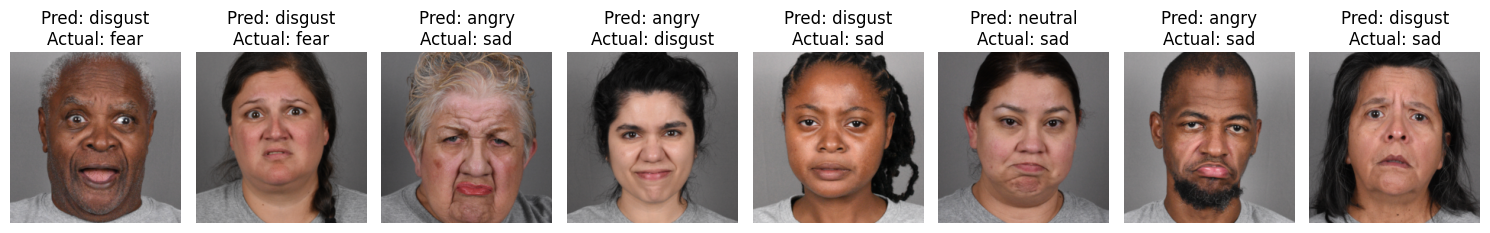

In [ ]:
show_incorrect_examples(KDEFxDiverse_incorrect_images, KDEFxDiverse_incorrect_labels, KDEFxDiverse_incorrect_preds, num=8)

## Confusion Matrices

Define a general confusion matrix and display function, hardcoding the size of the matrix to be 7x7 (for the 7 emotions)

In [ ]:
def confusion_matrix(labels, preds):
    # Initialize the confusion matrix as a zero matrix of size 7x7 (for 7 emotions)
    conf_matrix = np.zeros((7, 7), dtype=int)

    # Loop through the predictions and labels, and update the confusion matrix
    for true_label, pred_label in zip(labels, preds):
        conf_matrix[true_label][pred_label] += 1

    return conf_matrix

In [ ]:
import pandas as pd
import seaborn as sns

class_names = ['afraid', 'angry', 'disgust', 'happy', 'neutral', 'sad', 'surprised']

def display_cm(conf_matrix, class_names, plt_title):
    df_cm = pd.DataFrame(conf_matrix, index=class_names, columns=class_names)
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(plt_title)
    plt.show()


### FER x JAFFE

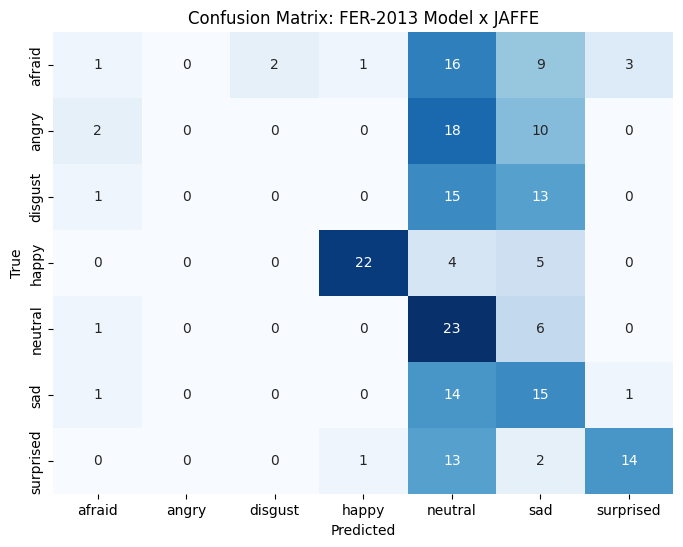

In [ ]:
FERxJAFFE_cm = confusion_matrix(FERxJAFFE_all_labels, FERxJAFFE_all_preds)
display_cm(FERxJAFFE_cm, class_names, "Confusion Matrix: FER-2013 Model x JAFFE")

### FER x DiverseFACES

In [ ]:
FERxDiverse_cm = confusion_matrix(FERxDiverse_all_labels, FERxDiverse_all_preds)
display_cm(FERxDiverse_cm, class_names, "Confusion Matrix: FER-2013 Model x DiverseFACES")

### KDEF x JAFFE

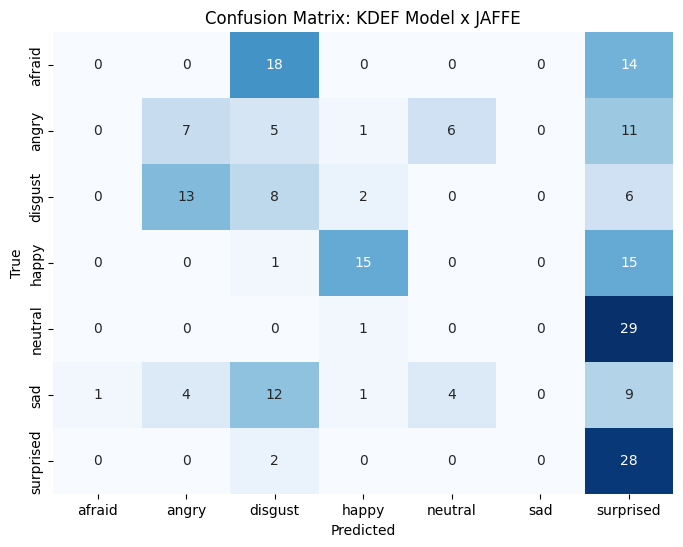

In [ ]:
KDEFxJAFFE_cm = confusion_matrix(KDEFxJAFFE_all_labels, KDEFxJAFFE_all_preds)
display_cm(KDEFxJAFFE_cm, class_names, "Confusion Matrix: KDEF Model x JAFFE")

### KDEF x DiverseFACES

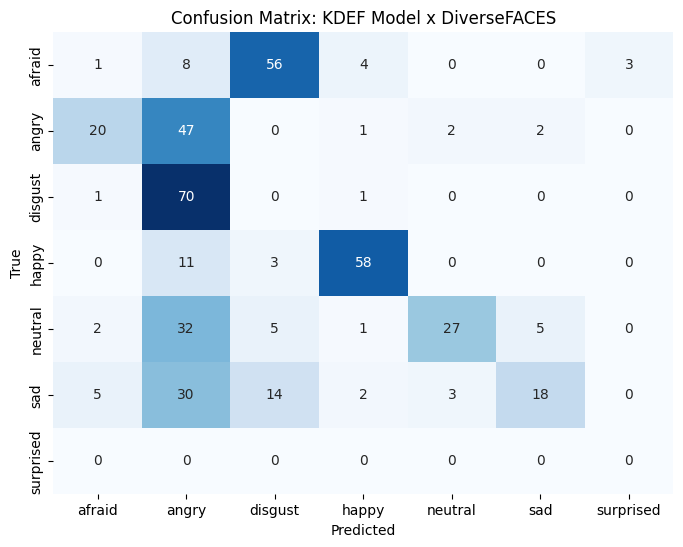

In [ ]:
KDEFxDiverse_cm = confusion_matrix(KDEFxDiverse_all_labels, KDEFxDiverse_all_preds)
display_cm(KDEFxDiverse_cm, class_names, "Confusion Matrix: KDEF Model x DiverseFACES")